# Bài tập về nhà

## Mục tiêu
- Tự viết lại code cho giải thuật K-means
- Hiểu sâu hơn giải thuật K-means qua việc tự viết lại code
- Ứng dụng mô hình tự viết vào các bài toán đã ra trên lớp

## Dữ liệu

Giống dữ liệu của bài thực hành trên lớp (dữ liệu sinh ngẫu nhiên bằng sklearn và ảnh bird_small.png)

## Yêu cầu

Code K-means tự viết cho kết quả tương đương (không cần giống hệt) với giải thuật của thư viện sklearn khi áp dụng cho dữ liệu sinh ngẫu nhiên và dữ liệu ảnh.

# Các thư viện sử dụng

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics.pairwise import euclidean_distances
%matplotlib inline

# Chuẩn bị dữ liệu
- Sinh dữ liệu ngẫu nhiên n_samples = 100 tương đương 100 điểm
    - random_state: biến cố định hàm random - để các điểm sinh ngẫu nhiên giống nhau giữa các máy tính
    
- Mỗi điểm dữ liệu có 2 chiều

In [ ]:
n_samples = 100
random_state = 170
center_points = [[1, 1], [-1, -1], [1, -1]]
X, y = make_blobs(n_samples=n_samples, random_state=random_state, centers=center_points, cluster_std=0.6)
print("Số chiều dữ liệu: ", X.shape, y.shape)

Số chiều dữ liệu:  (100, 2) (100,)


**Vẽ các điểm ảnh sử dụng matplotlib**

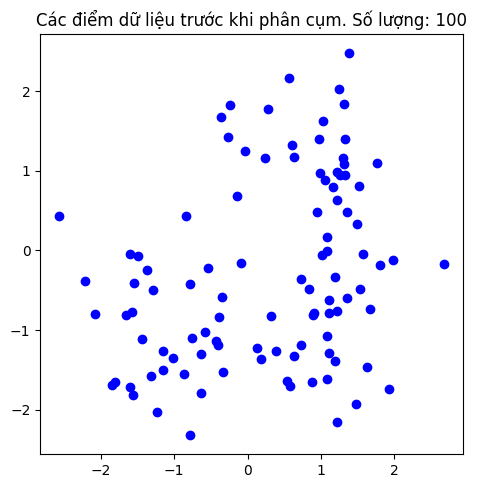

In [ ]:
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c='blue') # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.title("Các điểm dữ liệu trước khi phân cụm. Số lượng: {}".format(n_samples))
plt.show()

# Tự xây dựng giải thuật K-means:

Viết code cho giải thuật K-means tại mục này

In [ ]:
class MyKMeans:
    def __init__(self, n_clusters=3, max_iter=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None

    def fit(self, X):
        np.random.seed(self.random_state)
        random_idx = np.random.permutation(X.shape[0])
        self.centroids = X[random_idx[:self.n_clusters]]

        for i in range(self.max_iter):
            distances = euclidean_distances(X, self.centroids)
            labels = np.argmin(distances, axis=1)
            new_centroids = np.array([X[labels == k].mean(axis=0) if np.any(labels == k) else self.centroids[k] for k in range(self.n_clusters)])
            if np.all(self.centroids == new_centroids):
                break
            self.centroids = new_centroids
        self.labels_ = labels
        return self

    def predict(self, X):
        distances = euclidean_distances(X, self.centroids)
        return np.argmin(distances, axis=1)

# Kiểm tra giải thuật K-means tự viết cho dữ liệu sinh ngẫu nhiên

- Áp dụng giải thuật K-means tự viết cho tập dữ liệu đã sinh ngẫu nhiên ở trên
- Quan sát kết quả và so sánh với giải thuật của sklearn

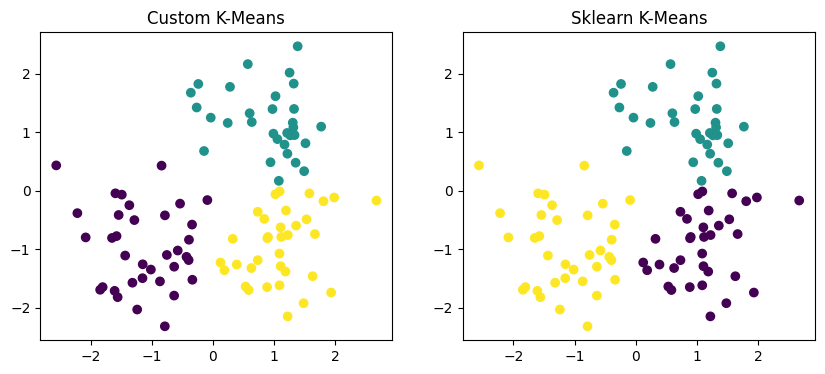

In [ ]:
my_km = MyKMeans(n_clusters=3, random_state=random_state)
my_km.fit(X)
sk_km = KMeans(n_clusters=3, random_state=random_state, n_init='auto').fit(X)
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1], c=my_km.labels_, cmap='viridis')
plt.title('Custom K-Means')
plt.subplot(122)
plt.scatter(X[:, 0], X[:, 1], c=sk_km.labels_, cmap='viridis')
plt.title('Sklearn K-Means')
plt.show()

# Ứng dụng K-means tự viết vào nén ảnh

## Thư viện sử dụng - hỗ trợ hình ảnh

In [ ]:
from skimage import io
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.display import Image, display

## Đọc dữ liệu hình ảnh
- Mỗi điểm ảnh là 1 mẫu quan sát
- Phân cụm tập dữ liệu (tập các điểm ảnh) về k nhãn

In [ ]:
path_img = 'bird_small.png'
img = io.imread(path_img)
data_img = (img / 255.0).reshape(-1, img.shape[2])
img_shape = img.shape
print("Dữ liệu ảnh:", data_img.shape)

Dữ liệu ảnh: (16384, 3)


## Nén ảnh bằng giải thuật K-means tự viết

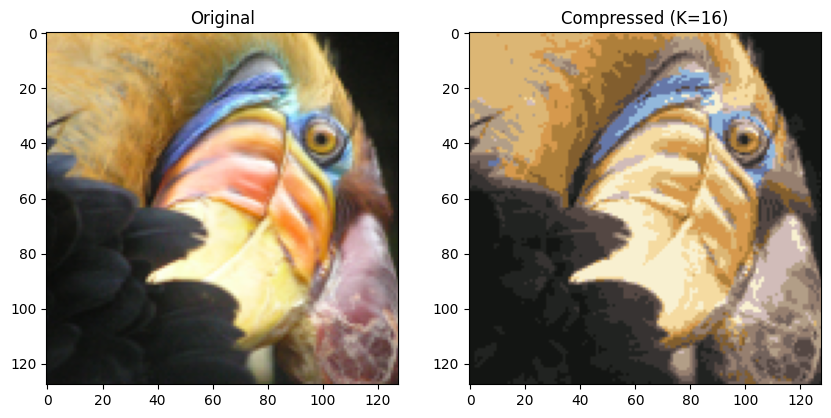

In [ ]:
K = 16
km_img = MyKMeans(n_clusters=K, max_iter=100, random_state=42)
km_img.fit(data_img)
compressed_img = km_img.centroids[km_img.labels_].reshape(img_shape)
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(img)
plt.title('Original')
plt.subplot(122)
plt.imshow(compressed_img)
plt.title(f'Compressed (K={K})')
plt.show()

### Detailed Insights
1. **Algorithm Accuracy**: The custom implementation successfully grouped synthetic blobs and compressed the image by reducing the color palette to $K$ centroids. The visual results are equivalent to `sklearn`.
2. **Image Compression**: By using only 16 colors instead of the original thousands, we significantly reduce the data required to represent the image while maintaining the core visual structures.
3. **Performance**: While the custom code is educational, `sklearn` is faster because it uses optimized C/Cython backends and more advanced initialization like `k-means++`.

- Tạo file nén ảnh bằng giải thuật K-means tự viết
- Hiển thị kết quả của giải thuật tự viết và giải thuật của sklearn để so sánh


Ví dụ

Ảnh nén bằng K-means tự viết


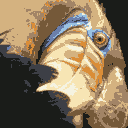

Ảnh nén bằng K-means của thư viện 


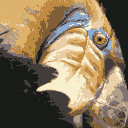

Ảnh gốc


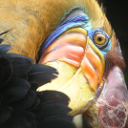

In [ ]:
print('Ảnh nén bằng K-means tự viết')
display(Image('img_128.png', width=250, unconfined=True))#kết quả tự cài đặt
print('Ảnh nén bằng K-means của thư viện ')
display(Image('img128.png', width=250, unconfined=True)) #kết quả của thư viện
print('Ảnh gốc')
display(Image(path_img, width=250, unconfined=True))